## Train the PF-Controller Neural Network

For each performance metric, train the corresponding particle-filter (PF) controller neural network.

In [ ]:
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import torch.nn as nn
from src.models.particle_filter.core import ParticleFilter
from src.models.networks.pf_mlp import ParticleFilterMLP
from src.helpers.seed import set_global_seed

from experiment_config import (
    DegModel,DATA_NAME,SEED,LEAKY_SLOPE,HIDDEN_DIMS,PREDICTION_START_IDX,LOSS_WINDOW_SIZE,N_PARTICLES,GRADIENT_CLIP,WEIGHT_DECAY,PFNET_DIR,DATA_DIR,DEGR_MODEL_DIR
)
    
DATA_NAME

'DS03'

## Task

In [ ]:
perform_name = 'T48'

## Hyper-Parameters

In [ ]:
# Training parameters#
# optimization
lr = 5e-4

# Early stopping
n_epochs = 5000
patience = 100         # how many eval steps to wait
min_delta = 1e-4       # minimum improvement to count

In [ ]:

activation = nn.LeakyReLU(LEAKY_SLOPE)

set_global_seed(SEED)
checkpoint_best_path = PFNET_DIR / perform_name / "checkpoint_best.pt"
checkpoint_last_path = PFNET_DIR / perform_name / "checkpoint_last.pt"
checkpoint_best_path.parent.mkdir(parents=True, exist_ok=True)

## Import training data

In [ ]:
hi_df = pd.read_csv(DATA_DIR/"data_dev.csv")
units = hi_df['unit'].astype(int).unique().tolist()
units 

[1, 2, 3, 4, 5, 6, 7, 8, 9]

### Extract degradation onset

In [ ]:
onsets = {unit: hi_df[(hi_df['unit']==unit) & (hi_df['hs']==0)]['cycle'].values[0] for unit in units}
del hi_df['hs']

In [ ]:
perform_names = [col for col in hi_df.columns if col not in ['unit','cycle']]

performs = {name: 
    {unit: hi_df[hi_df['unit']==unit][name].values for unit in units} 
    for name in perform_names
}

init_ss = {name: {unit: perform[unit].max() for unit in units} for name,perform in performs.items()}
time = {unit: hi_df[hi_df['unit']==unit]['cycle'].values for unit in units}

## Create component (base) models

In [ ]:
train_data = {}
train_eol = {}
degmodels = {}
for unit in units:
    t_data = time[unit]
    s_data = performs[perform_name][unit]
    train_data[unit]=torch.tensor(np.stack([t_data, s_data],axis=1),dtype=torch.float32)
    train_eol[unit]=torch.tensor(t_data[-1],dtype=torch.float32) 
    best_model = DegModel(onset=onsets[unit], init_s=init_ss[perform_name][unit])
    best_model.load_state_dict(
        torch.load(DEGR_MODEL_DIR/'states'/perform_name/f'unit_{unit}'/ "best_model.pt")
    )
    degmodels[unit]=best_model

In [ ]:
degmodels = {}
for train_unit in units:
    offline_degmodels=[]
    for unit, perform in performs[perform_name].items():
        if unit == train_unit:
            continue
        best_model = DegModel(onset=onsets[unit], init_s=init_ss[perform_name][unit])
        best_model.load_state_dict(
            torch.load(DEGR_MODEL_DIR/'states'/perform_name/f'unit_{unit}'/ "best_model.pt")
        )
        offline_degmodels.append(best_model)
    [tradegmodelsin_unit] = offline_degmodels

## Train Particle Filter Net()

In [ ]:
net = ParticleFilterMLP(state_dim=DegModel.state_dim(), hidden_dims=HIDDEN_DIMS,
                        activation=lambda : activation)

optimizer = torch.optim.Adam(net.parameters(), lr, weight_decay=WEIGHT_DECAY)
optimizer.zero_grad()

In [ ]:
wait = 0
best_score = float("inf")

all_epoch_unit_losses = []
mean_losses = []
std_losses = []
scores = []
epochs = []

start_epoch = 0

if checkpoint_last_path.exists():
    ckpt = torch.load(checkpoint_last_path, weights_only=False)

    net.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    start_epoch = ckpt["epoch"] + 1
    best_score = ckpt["best_score"]

    mean_losses = ckpt["mean_losses"]
    std_losses = ckpt["std_losses"]
    scores = ckpt["scores"]
    epochs = ckpt["epochs"]
    all_epoch_unit_losses = ckpt["all_epoch_unit_losses"]

    torch.random.set_rng_state(ckpt["rng_torch"])
    np.random.set_state(ckpt["rng_numpy"])

    print(f"✓ Resumed from epoch {start_epoch}, best_score={best_score:.3f}")

In [ ]:
for epoch in range(start_epoch, n_epochs):

    epoch_unit_losses = {}

    for train_unit in np.random.permutation(units):

        optimizer.zero_grad()

        offline_degmodels = degmodels[train_unit]
        t_data = train_data[train_unit][:, 0]
        s_data = train_data[train_unit][:, 1]

        pf = ParticleFilter(
            base_models=offline_degmodels,
            net=net,
            n_particles=N_PARTICLES,
        ).train()

        unit_loss = 0.0
        n_loss = 0

        for k in range(PREDICTION_START_IDX, len(t_data)):

            mixture_dist = pf.step(
                t_obs=t_data[:k+1],
                s_obs=s_data[:k+1],
            )

            init_loss = -1 if USE_LASTOBS_LOSS else k
            last_dist = mixture_dist.distribution(s=s_data[init_loss:])
            nll = -last_dist.log_prob(t_data[init_loss:]).mean()

            unit_loss += nll
            n_loss += 1

        unit_loss = unit_loss / n_loss

        unit_loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRADIENT_CLIP)
        optimizer.step()

        epoch_unit_losses[train_unit] = unit_loss.item()

    # ---- compute mean + 0.5 * std ----
    unit_values = np.array(list(epoch_unit_losses.values()))
    mean_loss = unit_values.mean()
    std_loss = unit_values.std()

    score = mean_loss + 0.5 * std_loss

    print(
        f"[Epoch {epoch:04d}] "
        f"mean={mean_loss:.3f} | std={std_loss:.3f} | score={score:.3f}"
    )

    all_epoch_unit_losses.append(epoch_unit_losses)
    mean_losses.append(mean_loss)
    std_losses.append(std_loss)
    scores.append(score)
    epochs.append(epoch)

    # ---- early stopping on score ----
    if score < best_score - min_delta:
        best_score = score
        wait = 0

        # ---- BEST (minimal) ----
        best_checkpoint = {
            'epoch': epoch,
            'model_state': net.state_dict(),
            'best_score': best_score,
        }
        torch.save(best_checkpoint, checkpoint_best_path)
        

        # ---- LAST (full training state) ----
        last_checkpoint = {
            'epoch': epoch,
            'model_state': net.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_score': best_score,
            'mean_losses': mean_losses,
            'std_losses': std_losses,
            'scores': scores,
            'epochs': epochs,
            'all_epoch_unit_losses': all_epoch_unit_losses,
            "rng_torch": torch.random.get_rng_state(),
            "rng_numpy": np.random.get_state(),
        }
        torch.save(last_checkpoint, checkpoint_last_path)
        print("  + saved")
    else:
        wait += 1
        if wait >= patience:
            print("🛑 Early stopping triggered")
            break

[Epoch 0000] mean=3.435 | std=0.588 | score=3.729
  + saved
[Epoch 0001] mean=3.432 | std=0.614 | score=3.739
[Epoch 0002] mean=3.453 | std=0.577 | score=3.741
[Epoch 0003] mean=3.411 | std=0.533 | score=3.678
  + saved
[Epoch 0004] mean=4.654 | std=3.831 | score=6.569
[Epoch 0005] mean=3.713 | std=1.490 | score=4.458
[Epoch 0006] mean=3.437 | std=0.534 | score=3.704
[Epoch 0007] mean=3.334 | std=0.552 | score=3.609
  + saved
[Epoch 0008] mean=3.443 | std=0.593 | score=3.739
[Epoch 0009] mean=3.391 | std=0.605 | score=3.694
[Epoch 0010] mean=3.278 | std=0.449 | score=3.503
  + saved
[Epoch 0011] mean=3.272 | std=0.428 | score=3.486
  + saved
[Epoch 0012] mean=3.308 | std=0.441 | score=3.528
[Epoch 0013] mean=3.338 | std=0.486 | score=3.581
[Epoch 0014] mean=3.461 | std=1.001 | score=3.962
[Epoch 0015] mean=3.271 | std=0.413 | score=3.477
  + saved
[Epoch 0016] mean=3.239 | std=0.376 | score=3.427
  + saved
[Epoch 0017] mean=3.317 | std=0.495 | score=3.565
[Epoch 0018] mean=3.283 | std=

# Save last results

In [ ]:
# ---- Always save LAST at end of training ----
last_checkpoint = {
    'epoch': epoch,
    'model_state': net.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'best_score': best_score,
    'mean_losses': mean_losses,
    'std_losses': std_losses,
    'scores': scores,
    'epochs': epochs,
    'all_epoch_unit_losses': all_epoch_unit_losses,
    "rng_torch": torch.random.get_rng_state(),
    "rng_numpy": np.random.get_state(),
}

torch.save(last_checkpoint, checkpoint_last_path)
print("✓ Final LAST checkpoint saved.")

✓ Final LAST checkpoint saved.


## Plot

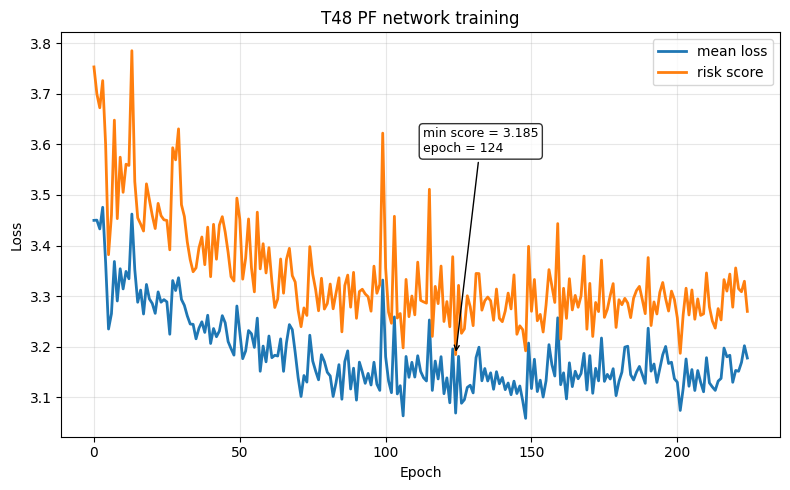

✓ Plot saved to experiments/DS03/estimation_thr0.1_q0.01-0.99_filtered_n0.01_s20.0/gamma_onset0.2-0.2/pf_performs/net256x256x128x64x32leaky0.05_gradclip3.0_wdecay0.0001_riskSL0.5_test/T48/net_training_loss.png
✓ Best epoch: 124 (score=3.1847)


In [ ]:
epochs_arr = np.array(epochs)
mean_arr = np.array(mean_losses)
std_arr = np.array(std_losses)
scores_arr = np.array(scores)

best_idx = np.argmin(scores_arr)
best_epoch = epochs_arr[best_idx]
best_score = scores_arr[best_idx]

plt.figure(figsize=(8, 5))

# Main curves
plt.plot(epochs_arr, mean_arr, linewidth=2, label='mean loss')
plt.plot(epochs_arr, scores_arr, linewidth=2, label='risk score')



ymin, ymax = plt.ylim()
yrange = ymax - ymin

y_offset = 0.5 * yrange      # 8% of axis height
x_offset = -0.05 * (epochs_arr.max() - epochs_arr.min())

# ---- Annotation instead of scatter ----
plt.annotate(
    f"min score = {best_score:.3f}\nepoch = {best_epoch}",
    xy=(best_epoch, best_score),
    xytext=(best_epoch + x_offset, best_score + y_offset),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", linewidth=1),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{perform_name} PF network training')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
fig_path = pfnet_dir / perform_name / "net_training_loss.png"
plt.savefig(fig_path, dpi=300)

# Save raw arrays
np.save(pfnet_dir / perform_name / "net_training_mean.npy", mean_arr)
np.save(pfnet_dir / perform_name / "net_training_std.npy", std_arr)
np.save(pfnet_dir / perform_name / "net_training_scores.npy", scores_arr)

plt.show()

print(f"✓ Plot saved to {fig_path}")
print(f"✓ Best epoch: {best_epoch} (score={best_score:.4f})")